In [13]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

from ang_res_funcs import get_cosine_binning

In [14]:
# Load in the SIBYLL2.1 particle sims - note that these will also be your variable names
year = 2012
model = 'SIBYLL2.1'

KEYS = ['energy', 'particle_type', 'hits', 'reco_pass', 'showerplane_zen', 'laputop_az', 'laputop_zen', 'true_azimuth', 'true_zenith', 'Gweights']

for key in KEYS:
    with open(f'/data/user/tfutrell/it_anisotropy/{year}/{model}/{key}.npy', 'rb') as file:
        globals()[key] = np.load(file)

In [15]:
# IceTop setup

# Define a function for weighted medians, or weighted quantiles
def weighted_quantiles(values, weights, quantiles=[0.5]):
    if len(values) == 0:
        return 0
    else:
        i = np.argsort(values)
        c = np.cumsum(weights[i])
        return values[i[np.searchsorted(c, np.asarray(quantiles) * c[-1])]]

# Composition cuts
IT_COMPS = {
    'proton': particle_type == 2.21200000e+03,
    'helium': particle_type == 1.00002004e+09,
    'oxygen': particle_type == 1.00008016e+09,
    'iron'  : particle_type == 1.00026056e+09
}

# Directional reconstruction cuts
plane_cut   = (showerplane_zen < np.radians(55))
laputop_cut = (laputop_zen < np.radians(55))
reco_cut    = (reco_pass == 1)

# Energy tier cuts
offset = np.ceil((year - 2011)/2)
TIERS = {
    'Tier 1': (3 <= hits) * (hits < 5),
    'Tier 2': (5 <= hits) * (hits < 10 - offset),
    'Tier 3': (10 - offset <= hits) * (hits < 17 - offset),
    'Tier 4': (17 - offset <= hits)
}

# Weights
it_weights = Gweights

In [22]:
# Titles of figures
titles = ['280 TeV', '900 TeV', '2.3 PeV', '6.6 PeV']

In [23]:
zen_bins = get_cosine_binning(55, 10)
azi_bins = np.arange(0,361, 5)

binned_zenith = np.digitize(np.degrees(true_zenith), zen_bins) - 1

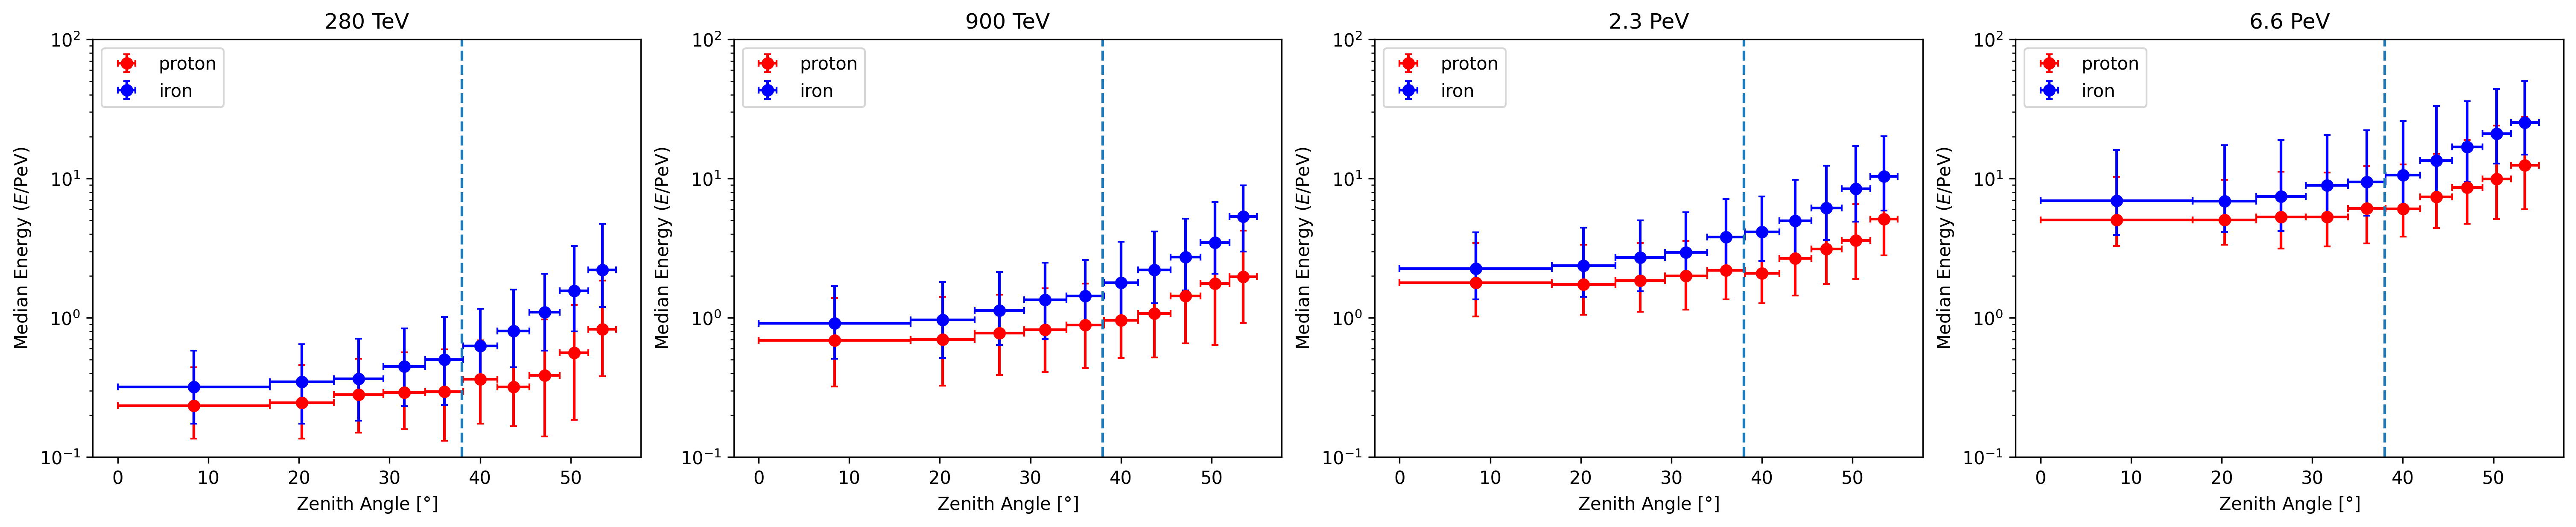

In [25]:
fig = plt.figure(figsize=(20, 4), constrained_layout=True, dpi = 300)
ax_array = fig.subplots(1, 4, squeeze=False)
#fig.suptitle('Log Median Energy vs Zenith Angle')

for i, (tier, tier_cut) in enumerate(TIERS.items()):

    # Calculate bin centers and half-widths for each bin
    zen_centers = (zen_bins[:-1] + zen_bins[1:])/2
    xerr = zen_centers - zen_bins[:-1]
    
    for comp in ['proton','iron']:

        comp_cut = IT_COMPS[comp]
        color = 'blue' if comp=='iron' else 'red'

        quantile_data = []

        for j in range(len(zen_centers)):

            zen_cut = (binned_zenith == j)

            if tier == 'Tier 1':
                cut = tier_cut * comp_cut * zen_cut * plane_cut 
            else:
                cut = tier_cut * comp_cut * zen_cut * laputop_cut * reco_cut

            quantile_data += [weighted_quantiles(energy[cut], it_weights[cut], quantiles=[0.5,0.16,0.84])]
            
        median, ql, qh = np.transpose(quantile_data) / 1e6
        ql = median - ql
        qh = qh - median

        ax_array[0,i].errorbar(zen_centers, median, xerr=xerr, yerr=[ql, qh], capsize=2, fmt='o', color=color, label=comp)

        ax_array[0,i].set_title(titles[i])
    
    ax_array[0,i].set_yscale('log')
    ax_array[0,i].vlines(38, 0, 2000, linestyle = 'dashed')
    ax_array[0,i].set_ylim(.1,100)
    ax_array[0,i].set_ylabel(r'Median Energy ($E$/PeV)')
    ax_array[0,i].set_xlabel(r'Zenith Angle [$\degree$]')
    ax_array[0,i].legend(loc='upper left')

plt.savefig('Figure-Energy-Response-Alternate-v2.pdf')
